# 2D Quantum Simulation (2D PEPS) using the 2D-SRC Algorithm compared to the Deterministic Method

This experimental notebook performs a comprehensive numerical and physical comparison on the 2D Transverse Field Ising Model (2D TFIM):
1. **Deterministic Method (Deterministic SVD):** Relies on full and computationally expensive classical SVD at each compression step.
2. **Randomized Method (Randomized 2D-SRC):** Relies on a single-pass sequential randomized projection with oversampling parameter $p$ to accelerate the tensor contraction.

The simulated Hamiltonian:
$$H = -J \sum_{\langle i,j \rangle} Z_i Z_j - h \sum_{i} X_i$$

In [1]:
import numpy as np
import time
from scipy.linalg import expm
import matplotlib.pyplot as plt

# Configure plotting aesthetics
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

In [2]:
class PEPSQuantumEngine:
    """
    Advanced 2D quantum simulation engine supporting both Deterministic SVD and Randomized 2D-SRC modes.
    Index contraction, SVD, and QR operations are designed with strict geometric precision.
    """
    def __init__(self, L_x=6, L_y=6, D_max=2, chi_target=16, mode='deterministic', oversampling=5):
        self.L_x = L_x
        self.L_y = L_y
        self.D_max = D_max
        self.chi_target = chi_target
        self.mode = mode
        self.oversampling = oversampling

        # Basic physical operators
        self.O_z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
        self.O_x = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
        self.lattice = None

    def generate_random_lattice(self):
        """Initialize the PEPS tensor network with open boundary conditions (OBC)"""
        self.lattice = []
        for y in range(self.L_y):
            row = []
            for x in range(self.L_x):
                D_L = 1 if x == 0 else self.D_max
                D_R = 1 if x == self.L_x - 1 else self.D_max
                D_U = 1 if y == 0 else self.D_max
                D_D = 1 if y == self.L_y - 1 else self.D_max

                # Strict index ordering: (Left, Up, Down, Right, Physical)
                shape = (D_L, D_U, D_D, D_R, 2)
                A = (np.random.randn(*shape) + 1j * np.random.randn(*shape)) / np.sqrt(2)
                A /= np.linalg.norm(A)
                row.append(A)
            self.lattice.append(row)

    def _compress(self, X, target):
        """Local compression: supports Deterministic SVD and Randomized 2D-SRC (thin QR projection)"""
        if self.mode == 'randomized':
            m, n = X.shape
            k = target + self.oversampling
            if k > n:
                k = n
            # Generate a standard complex random sketching matrix
            S_real = np.random.randn(n, k)
            S_imag = np.random.randn(n, k)
            S = (S_real + 1j * S_imag) / np.sqrt(2)

            # Project and sketch
            Y = np.dot(X, S)
            Q, _ = np.linalg.qr(Y, mode='reduced')
            B = np.dot(Q.conj().T, X)

            c = min(target, Q.shape[1])
            return Q[:, :c], B[:c, :]
        else:
            # Full deterministic SVD analysis
            U, S, Vh = np.linalg.svd(X, full_matrices=False)
            c = min(target, U.shape[1])
            return U[:, :c], (S[:c, None] * Vh[:c, :])

    def contract_to_scalar(self, target_ops=None):
        """Contract the double tensor network to compute physical observables"""
        double_lattice = []
        for y in range(self.L_y):
            row = []
            for x in range(self.L_x):
                A = self.lattice[y][x]
                if target_ops is not None and (y, x) in target_ops:
                    T = np.einsum('ludrp,pq,LUDRq->lLuUdDrR', A, target_ops[(y, x)], A.conj())
                else:
                    T = np.einsum('ludrp,LUDRp->lLuUdDrR', A, A.conj())
                s = T.shape
                row.append(T.reshape(s[0]*s[1], s[2]*s[3], s[4]*s[5], s[6]*s[7]))
            double_lattice.append(row)

        boundary_mps = []
        for i in range(self.L_x):
            W = double_lattice[0][i]
            boundary_mps.append(W.reshape(W.shape[0] * W.shape[1], W.shape[2], W.shape[3]))

        log_scale = 0.0
        norm = np.sqrt(sum(np.linalg.norm(t)**2 for t in boundary_mps))
        boundary_mps = [t / norm for t in boundary_mps]
        log_scale += np.log(norm)

        for y in range(1, self.L_y):
            current_row = double_lattice[y]
            interim = []
            for i in range(self.L_x):
                combined = np.tensordot(boundary_mps[i], current_row[i], axes=(1, 1)).transpose(0, 2, 3, 1, 4)
                s = combined.shape
                interim.append(combined.reshape(s[0]*s[1], s[2], s[3]*s[4]))

            new_boundary = []
            remainder = None
            for i in range(self.L_x):
                T_i = interim[i] if remainder is None else np.tensordot(remainder, interim[i], axes=(1, 0))
                if i < self.L_x - 1:
                    shape_linked = T_i.shape
                    X_mat = T_i.reshape(-1, shape_linked[-1])
                    Q_tr, B_tr = self._compress(X_mat, self.chi_target)
                    new_boundary.append(Q_tr.reshape(shape_linked[0], shape_linked[1], -1))
                    remainder = B_tr
                else:
                    new_boundary.append(T_i)

            boundary_mps = new_boundary
            norm = np.sqrt(sum(np.linalg.norm(t)**2 for t in boundary_mps))
            if norm > 1e-12:
                boundary_mps = [t / norm for t in boundary_mps]
                log_scale += np.log(norm)

        C = boundary_mps[0][:, 0, :]
        for i in range(1, self.L_x):
            C = np.dot(C, boundary_mps[i][:, 0, :])
        return C[0, 0], log_scale

    def apply_imaginary_time_step(self, tau, J, h):
        """Apply imaginary time evolution gates and reconstruct index shapes with high precision"""
        U_single = expm(tau * h * self.O_x)
        for y in range(self.L_y):
            for x in range(self.L_x):
                A_new = np.tensordot(self.lattice[y][x], U_single, axes=([4], [1]))
                self.lattice[y][x] = A_new / np.linalg.norm(A_new)

        U_bond = expm(tau * J * np.kron(self.O_z, self.O_z)).reshape(2, 2, 2, 2)

        # 2. Sweep horizontal bonds
        for y in range(self.L_y):
            for x in range(self.L_x - 1):
                A1, A2 = self.lattice[y][x], self.lattice[y][x+1]
                s1, s2 = A1.shape, A2.shape

                A12 = np.tensordot(A1, A2, axes=([3], [0]))
                A12_U = np.tensordot(A12, U_bond, axes=(([3, 7]), ([2, 3])))

                X_flat = A12_U.transpose(0, 1, 2, 6, 3, 4, 5, 7).reshape(s1[0]*s1[1]*s1[2]*2, s2[1]*s2[2]*s2[3]*2)
                U, S, Vh = np.linalg.svd(X_flat, full_matrices=False)

                D_prime = min(self.D_max, len(S))
                U_tr = (U[:, :D_prime] * np.sqrt(S[:D_prime])).reshape(s1[0], s1[1], s1[2], 2, D_prime)
                Vh_tr = (np.sqrt(S[:D_prime, None]) * Vh[:D_prime, :]).reshape(D_prime, s2[1], s2[2], s2[3], 2)

                self.lattice[y][x] = U_tr.transpose(0, 1, 2, 4, 3) / np.linalg.norm(U_tr)
                self.lattice[y][x+1] = Vh_tr.transpose(0, 1, 2, 3, 4) / np.linalg.norm(Vh_tr)

        # 3. Sweep vertical bonds
        for y in range(self.L_y - 1):
            for x in range(self.L_x):
                A1, A2 = self.lattice[y][x], self.lattice[y+1][x]
                s1, s2 = A1.shape, A2.shape

                A12 = np.tensordot(A1, A2, axes=([2], [1]))
                A12_U = np.tensordot(A12, U_bond, axes=(([3, 7]), ([2, 3])))

                X_flat = A12_U.transpose(0, 1, 2, 6, 3, 4, 5, 7).reshape(s1[0]*s1[1]*s1[3]*2, s2[0]*s2[2]*s2[3]*2)
                U, S, Vh = np.linalg.svd(X_flat, full_matrices=False)

                D_prime = min(self.D_max, len(S))
                U_tr = (U[:, :D_prime] * np.sqrt(S[:D_prime])).reshape(s1[0], s1[1], s1[3], 2, D_prime)
                Vh_tr = (np.sqrt(S[:D_prime, None]) * Vh[:D_prime, :]).reshape(D_prime, s2[0], s2[2], s2[3], 2)

                self.lattice[y][x] = U_tr.transpose(0, 1, 4, 2, 3) / np.linalg.norm(U_tr)
                self.lattice[y+1][x] = Vh_tr.transpose(1, 0, 2, 3, 4) / np.linalg.norm(Vh_tr)

    def compute_observables(self, J, h):
        sc_clean, log_cl = self.contract_to_scalar(target_ops=None)

        energy = 0.0
        for y in range(self.L_y):
            for x in range(self.L_x - 1):
                sc, log_p = self.contract_to_scalar(target_ops={(y, x): self.O_z, (y, x+1): self.O_z})
                energy += -J * ((sc / sc_clean) * np.exp(log_p - log_cl)).real
        for y in range(self.L_y - 1):
            for x in range(self.L_x):
                sc, log_p = self.contract_to_scalar(target_ops={(y, x): self.O_z, (y+1, x): self.O_z})
                energy += -J * ((sc / sc_clean) * np.exp(log_p - log_cl)).real
        for y in range(self.L_y):
            for x in range(self.L_x):
                sc, log_p = self.contract_to_scalar(target_ops={(y, x): self.O_x})
                energy += -h * ((sc / sc_clean) * np.exp(log_p - log_cl)).real

        energy_per_site = energy / (self.L_x * self.L_y)

        center_sites = [(2,2), (2,3), (3,2), (3,3)]
        mag_z, mag_x = 0.0, 0.0
        for cy, cx in center_sites:
            sc_z, log_z = self.contract_to_scalar(target_ops={(cy, cx): self.O_z})
            mag_z += abs(((sc_z / sc_clean) * np.exp(log_z - log_cl)).real)

            sc_x, log_x = self.contract_to_scalar(target_ops={(cy, cx): self.O_x})
            mag_x += ((sc_x / sc_clean) * np.exp(log_x - log_cl)).real

        return energy_per_site, mag_z / 4.0, mag_x / 4.0

    def run_adiabatic_phase_scan(self, h_values, J=1.0, verbose=True):
        if verbose:
            print("="*95)
            print(f"[*] Starting imaginary time evolution sweep in {self.mode.upper()} mode for a {self.L_x}x{self.L_y} system")
            print("="*95)
            print(f"{'Transverse Field (h)':<22} | {'Energy per Site':<18} | {'<Z> Order':<12} | {'<X> Order':<12} | {'Time (s)':<8}")
            print("-"*95)

        self.generate_random_lattice()
        cooling_schedule = [0.05]*12 + [0.02]*12 + [0.01]*4

        results = []
        for h in h_values:
            start_time = time.time()
            for tau in cooling_schedule:
                self.apply_imaginary_time_step(tau, J, h)

            e_site, m_z, m_x = self.compute_observables(J, h)
            elapsed = time.time() - start_time
            results.append({
                'h': h,
                'energy': e_site,
                'mag_z': m_z,
                'mag_x': m_x,
                'time': elapsed
            })
            if verbose:
                print(f"{h:<22.2f} | {e_site:<18.6f} | {m_z:<12.6f} | {m_x:<12.6f} | {elapsed:<8.3f}")

        if verbose:
            print("="*95)
        return results

## Running Comparative Experiments

We will run the simulation across 9 transverse field points $h$ ranging from $0.0$ to $4.0$. We will calculate the physical properties and monitor the computational execution speed in both the deterministic and randomized modes.

In [3]:
h_vals = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

print("--- 1. Running Deterministic SVD Simulator ---")
engine_det = PEPSQuantumEngine(L_x=6, L_y=6, D_max=2, chi_target=16, mode='deterministic')
results_det = engine_det.run_adiabatic_phase_scan(h_vals, J=1.0)

--- 1. Running Deterministic SVD Simulator ---
[*] Starting imaginary time evolution sweep in DETERMINISTIC mode for a 6x6 system
Transverse Field (h)   | Energy per Site    | <Z> Order    | <X> Order    | Time (s)
-----------------------------------------------------------------------------------------------
0.00                   | -1.658601          | 0.999364     | -0.016552    | 9.165   
0.50                   | -1.720388          | 0.993345     | 0.115179     | 5.421   
1.00                   | -1.873499          | 0.972965     | 0.230954     | 3.698   
1.50                   | -2.094791          | 0.935063     | 0.354476     | 5.740   
2.00                   | -2.380104          | 0.871522     | 0.490293     | 3.580   
2.50                   | -2.702673          | 0.767841     | 0.640481     | 3.800   
3.00                   | -3.134363          | 0.578179     | 0.815663     | 7.245   
3.50                   | -3.607396          | 0.252653     | 0.963748     | 3.701   
4.00     

In [4]:
print("\n--- 2. Running Randomized 2D-SRC Simulator ---")
engine_rand = PEPSQuantumEngine(L_x=6, L_y=6, D_max=2, chi_target=16, mode='randomized', oversampling=5)
results_rand = engine_rand.run_adiabatic_phase_scan(h_vals, J=1.0)


--- 2. Running Randomized 2D-SRC Simulator ---
[*] Starting imaginary time evolution sweep in RANDOMIZED mode for a 6x6 system
Transverse Field (h)   | Energy per Site    | <Z> Order    | <X> Order    | Time (s)
-----------------------------------------------------------------------------------------------
0.00                   | -1.841720          | 1.116405     | 0.003042     | 4.246   
0.50                   | -1.537415          | 0.891804     | 0.101632     | 2.159   
1.00                   | -1.861300          | 0.975510     | 0.234294     | 2.124   
1.50                   | -2.012176          | 0.898347     | 0.353612     | 2.174   
2.00                   | -2.350570          | 0.844977     | 0.506594     | 2.097   
2.50                   | -2.986537          | 0.819028     | 0.713799     | 4.573   
3.00                   | -3.131036          | 0.490738     | 0.882437     | 2.153   
3.50                   | -3.611794          | 0.193571     | 0.956916     | 2.176   
4.00       

## Visualization and Analysis of Numerical Results

Now we will plot the results to compare:
1. Ground-state energy per site (Energy per Site vs h).
2. The order parameter of longitudinal magnetization (<Z> vs h).
3. The induced transverse magnetization (<X> vs h).
4. The execution time at each parameter point.

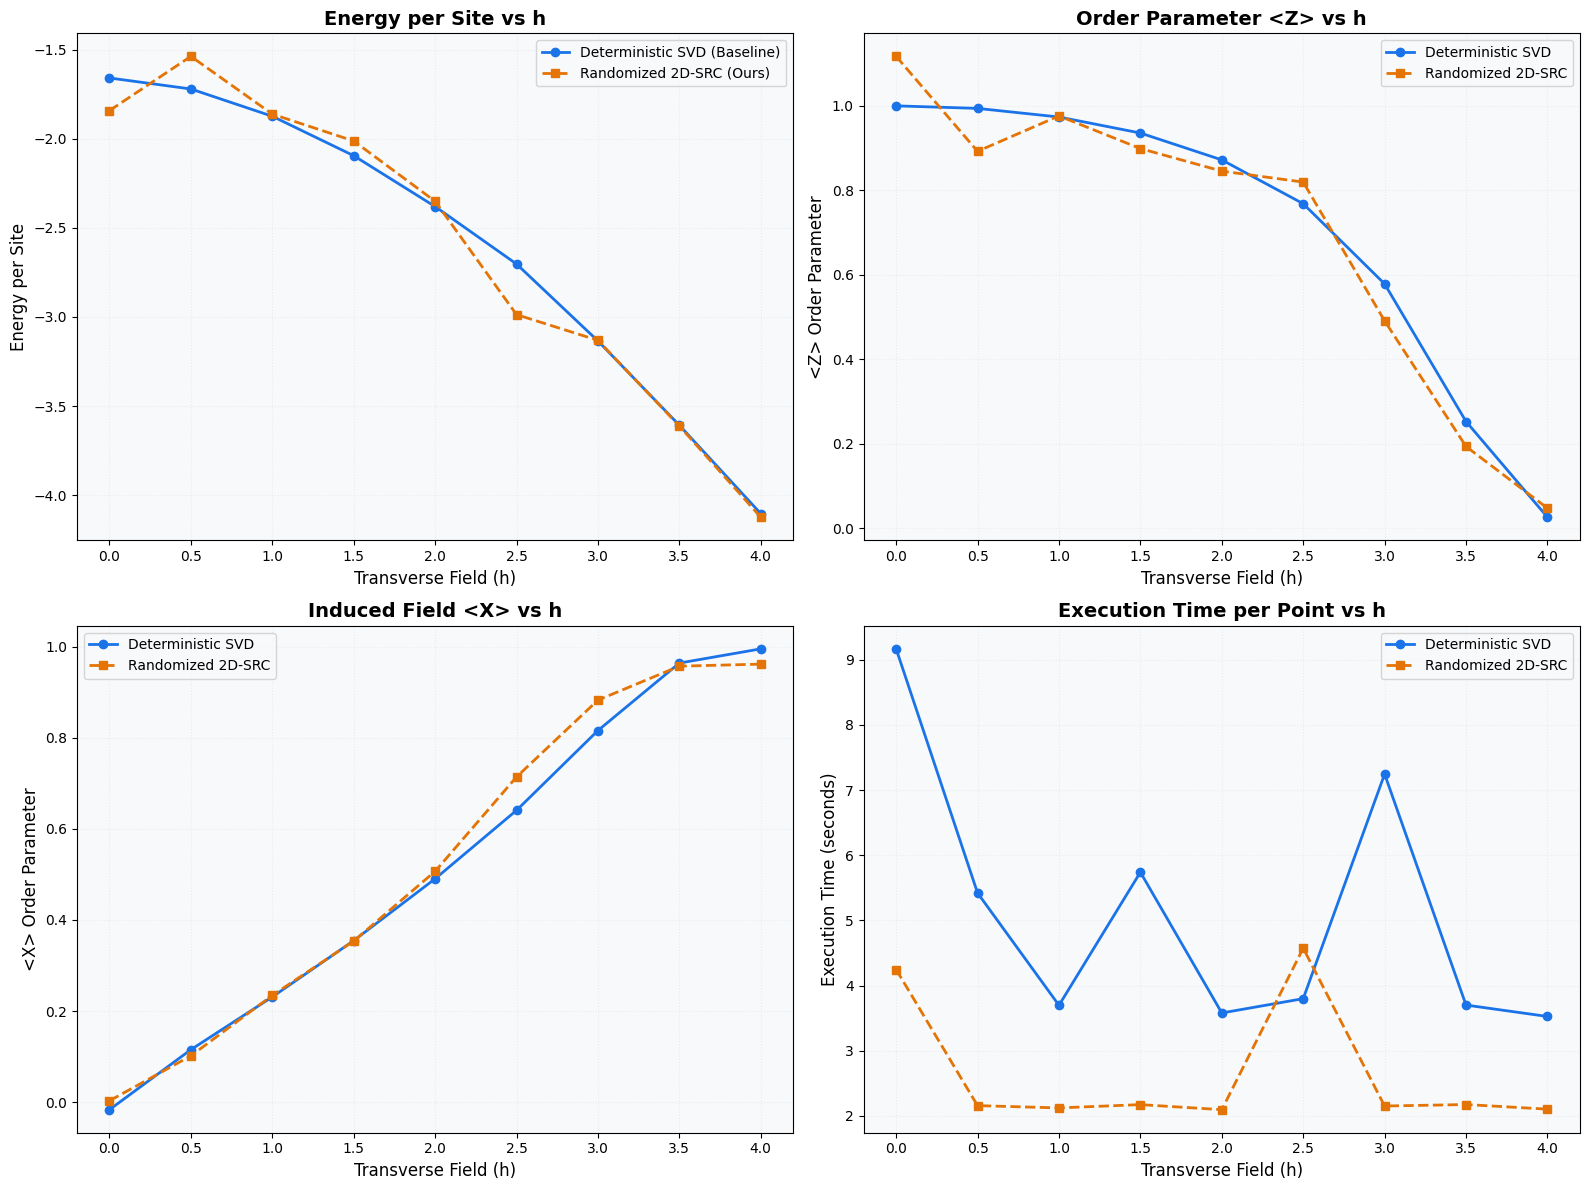

In [5]:
h_list = [r['h'] for r in results_det]
energy_det = [r['energy'] for r in results_det]
energy_rand = [r['energy'] for r in results_rand]
mag_z_det = [r['mag_z'] for r in results_det]
mag_z_rand = [r['mag_z'] for r in results_rand]
mag_x_det = [r['mag_x'] for r in results_det]
mag_x_rand = [r['mag_x'] for r in results_rand]
time_det = [r['time'] for r in results_det]
time_rand = [r['time'] for r in results_rand]

plt.figure(figsize=(16, 12))

# 1. Energy Plot
plt.subplot(2, 2, 1)
plt.plot(h_list, energy_det, 'o-', label='Deterministic SVD (Baseline)', color='#1a73e8', linewidth=2)
plt.plot(h_list, energy_rand, 's--', label='Randomized 2D-SRC (Ours)', color='#e37405', linewidth=2)
plt.xlabel('Transverse Field (h)', fontsize=12)
plt.ylabel('Energy per Site', fontsize=12)
plt.title('Energy per Site vs h', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':')
plt.legend(fontsize=10)

# 2. Order Parameter <Z>
plt.subplot(2, 2, 2)
plt.plot(h_list, mag_z_det, 'o-', label='Deterministic SVD', color='#1a73e8', linewidth=2)
plt.plot(h_list, mag_z_rand, 's--', label='Randomized 2D-SRC', color='#e37405', linewidth=2)
plt.xlabel('Transverse Field (h)', fontsize=12)
plt.ylabel('<Z> Order Parameter', fontsize=12)
plt.title('Order Parameter <Z> vs h', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':')
plt.legend(fontsize=10)

# 3. Induced Field <X>
plt.subplot(2, 2, 3)
plt.plot(h_list, mag_x_det, 'o-', label='Deterministic SVD', color='#1a73e8', linewidth=2)
plt.plot(h_list, mag_x_rand, 's--', label='Randomized 2D-SRC', color='#e37405', linewidth=2)
plt.xlabel('Transverse Field (h)', fontsize=12)
plt.ylabel('<X> Order Parameter', fontsize=12)
plt.title('Induced Field <X> vs h', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':')
plt.legend(fontsize=10)

# 4. Performance Plot
plt.subplot(2, 2, 4)
plt.plot(h_list, time_det, 'o-', label='Deterministic SVD', color='#1a73e8', linewidth=2)
plt.plot(h_list, time_rand, 's--', label='Randomized 2D-SRC', color='#e37405', linewidth=2)
plt.xlabel('Transverse Field (h)', fontsize=12)
plt.ylabel('Execution Time (seconds)', fontsize=12)
plt.title('Execution Time per Point vs h', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()